In [2]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
_eta = ["1.1", "1.2", 
        "1.3", "1.4", "1.5", "1.6", "1.7", "1.8", "1.9", "2.0", "3.0", "4.0", 
       "5.0", "6.0", "7.0", "8.0", "9.0", "10.0", "20.0", "30.0", "40.0", "100.0"]

In [4]:
def F(x, A, B, C, D):
    return A*np.exp((x-B)*C)+D

[-16.9799314    0.63523991   1.63953583 -15.16198869]


(-21.0, -14.0)

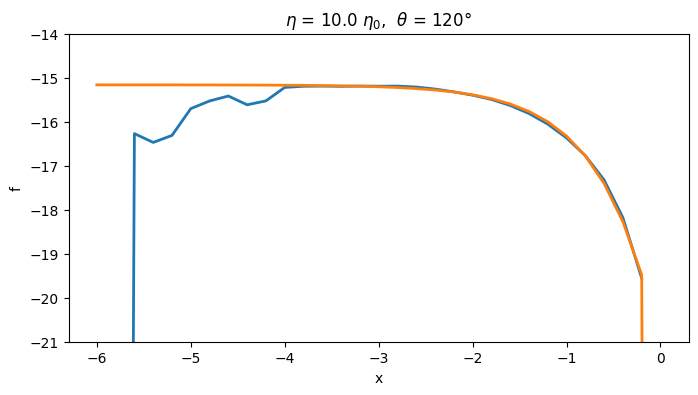

In [5]:
particle = "photon"

fig, ax = plt.subplots(1,1,figsize = (8, 4))

eta = 10.0
theta = 120

ax.set_title(rf"$\eta$ = {eta} $\eta_{0}$,  $\theta$ = {theta}$\degree$")

interp_file = (
    f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
)

x_i, spectrum = np.genfromtxt(
    interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
)
x_i = np.log10(np.where(x_i>0,x_i,1e-100))
spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

ax.plot(x_i,spectrum,lw=2,label=r"SOPHIA")

mask = (x_i >= -3) & (x_i <= 0)

x_fit = x_i[mask]
y_fit = spectrum[mask]

# popt, pcov = curve_fit(F, x_fit, y_fit)
popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-20,0.,0.,-19.],
                                                [-12,5.6,4.5,-12.]))
print(popt)

F_i = np.append(F(x_i, *popt),-100.)
x_i = np.append(x_i,0.)

ax.plot(x_i, F_i,lw=2,label=r"Fit")

ax.set_xlabel("x")
ax.set_ylabel("f")

# ax.set_xlim(1e-4,1)
# ax.set_ylim(1e-21,1e-14)
ax.set_ylim(-21,-14)

In [6]:
# count = 0
# for ii in range(0,6):
#     if(y_fit[ii] == 0.):
#         count=count+1
# y_fit = y_fit[:-count]

In [7]:
def fit_plot(particle):
    fig, ax = plt.subplots(22,19,figsize = (35, 20))

    fig.suptitle("Particle type: " + particle, fontsize=20)

    File = open(f"./integrand_values/Fx_{particle}.txt","x")

    print("#eta | theta | A | B | C | D    ||   F(x, A, B, C, D) = A*np.exp((x-B)*C)+D", file=File)

    i = 0
    for eta in _eta:
        j = 0
        for theta in range(0,190,10):
            interp_file = (
                f"./integrand_values/{particle}/{particle}_{eta}eta0_{theta}theta.txt"
            )

            x_i, spectrum = np.genfromtxt(
                interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
            )
            if(np.any(spectrum) == True):
                x_i = np.log10(np.where(x_i>0,x_i,1e-100))
                spectrum = np.log10(np.where(spectrum>0,spectrum,1e-100))

                ax[i,j].plot(x_i,spectrum,lw=2,label=r"SOPHIA")

                mask = (x_i >= -3) & (x_i <= 0)

                x_fit = x_i[mask]
                y_fit = spectrum[mask]

                count = 0
                for ii in range(0,6):
                    if(y_fit[len(y_fit)-ii-1] < -50.):
                        count=count+1
                if count!=0:
                    x_fit = x_fit[:-count]
                    y_fit = y_fit[:-count]

                popt, pcov = curve_fit(F, x_fit, y_fit, bounds=([-20,0.1,0.1,-20.],
                                                                [-12,5.6,4.5,-12.]))

                F_i = np.append(F(x_i, *popt),-100.)
                x_i = np.append(x_i,0.)

                # print(*popt, x_i[-2], file=File)
                print(eta,theta,*popt, file=File)

                ax[i,j].plot(x_i, F_i, lw=2, label=r"Fit")

                # ax[i,j].set_xlim(-4,0)
                ax[i,j].set_ylim(-20,-14)
            else:
                print(eta,theta, -100., 0., 0., 0., file=File)

            if i==0:
                ax[0,j].set_title(str(theta)+r"$\degree$")

            j = j+1
        
        ax[i,0].set_ylabel(eta+r" $\eta_{0}$")
        i=i+1

    File.close()


In [8]:
print(eta,theta,*popt,x_i[-2])

10.0 120 -16.979931404845644 0.6352399109198354 1.6395358345677298 -15.161988692725634 -0.20000023710935327


In [9]:
# fit_plot("photon")

In [10]:
# fit_plot("electron")
# fit_plot("positron")
# fit_plot("electron_neutrino")
# fit_plot("electron_antineutrino")
# fit_plot("muon_neutrino")
# fit_plot("muon_antineutrino")

In [11]:
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

particle = "photon"
data = np.loadtxt(f"./integrand_values/Fx_{particle}.txt")

eta = data[:, 0]
theta = data[:, 1]
params = data[:, 2:]

points = np.column_stack((eta, theta))

# interp = LinearNDInterpolator(points, params)
linear = LinearNDInterpolator(points, params)
nearest = NearestNDInterpolator(points, params)

def interp(eta, theta):
    val = linear(eta, theta)
    mask = np.isnan(val)
    
    if np.any(mask):
        val[mask] = nearest(eta, theta)[mask]
    
    return val

result = interp(1.1, 155)
print(result)

result = interp(1.1, 160)/2.
print(result)

[ -9.85332156   0.14746896   1.69307751 -58.6992995 ]
[-9.85332156  0.14746896  1.69307751 -8.6992995 ]


In [12]:
result = interp(10, 160)
print(result)

result = interp(101, 160)
print(result)

result = interp(1000, 160)
print(result)

[-16.92220508   0.60750118   1.61550641 -15.0368597 ]
[-16.77183526   0.64835892   1.2045558  -14.22109777]
[-16.77183526   0.64835892   1.2045558  -14.22109777]


In [59]:
eta_0 = 0.313

In [60]:
class Fx:
    def __init__(self, particle):
        data = np.loadtxt(f"./integrand_values/Fx_{particle}.txt")

        eta = data[:, 0]
        theta = data[:, 1]
        params = data[:, 2:]

        points = np.column_stack((eta*eta_0, theta))

        self.linear = LinearNDInterpolator(points, params)
        self.nearest = NearestNDInterpolator(points, params)

    def interp(self, eta, theta):
        pts = np.column_stack((np.atleast_1d(eta), np.atleast_1d(theta)))

        val = self.linear(pts)
        mask = np.isnan(val)

        if np.any(mask):
            val[mask] = self.nearest(pts)[mask]

        return val.squeeze()
    
    def F(self, x, A, B, C, D):
        return 10**(A*np.exp((x-B)*C)+D)
    
    def __call__(self, x, eta, theta):
        A, B, C, D = self.interp(eta, theta)
        # print(A,B,C,D)
        return np.where(x<0.8,self.F(np.log10(x), A, B, C, D),0.)

In [61]:
A = Fx("photon")
# A.interp(10,38)
# A(-5,101,20)
A(1e-3,30,25)

array(1.73912761e-17)

In [62]:
print(np.pi)
eta_0 = 0.313

3.141592653589793


In [63]:
from numpy import trapezoid

_x = 1e-2

theta = np.linspace(0., 180., 18*2)
vals = np.array([A(_x, 30.*eta_0, thetai)*np.sin(thetai*np.pi/180.) for thetai in theta])

result = np.trapezoid(vals, theta)/2.*np.pi/180.
# print(theta)
print(vals)
print(np.log10(result*_x))

[0.00000000e+000 8.96393089e-102 1.78556895e-101 2.66036846e-101
 3.95100868e-097 9.21846989e-054 9.50696974e-018 1.35414412e-017
 1.96023891e-017 4.46676606e-017 8.39835046e-017 1.03610571e-016
 1.25468233e-016 1.49936233e-016 1.79011219e-016 2.14801814e-016
 2.53081850e-016 2.92106305e-016 3.32436319e-016 3.73229270e-016
 4.11245725e-016 4.45400278e-016 4.73088504e-016 4.94146886e-016
 5.03880854e-016 5.04499221e-016 4.93243600e-016 4.72363205e-016
 4.40599244e-016 4.00632559e-016 3.49149311e-016 2.90584920e-016
 2.24172402e-016 1.53136149e-016 7.74872657e-017 1.06607787e-031]
-17.44875089758788


[np.float64(1.0431488390373186e-22), np.float64(1.1717934378263081e-22), np.float64(1.3163027911540581e-22), np.float64(1.4786333396575248e-22), np.float64(1.6609827805874246e-22), np.float64(1.8658198146425846e-22), np.float64(2.095917559512931e-22), np.float64(2.354391081779092e-22), np.float64(2.6447395543490294e-22), np.float64(2.970893608941956e-22), np.float64(3.337268523079403e-22), np.float64(3.7488239595320594e-22), np.float64(4.2111310642249993e-22), np.float64(4.730447827366918e-22), np.float64(5.313803723316669e-22), np.float64(5.969094768848422e-22), np.float64(6.705190278600068e-22), np.float64(7.532052752330029e-22), np.float64(8.460872503090102e-22), np.float64(9.504218830668596e-22), np.float64(1.067620976299309e-21), np.float64(1.1992702632146942e-21), np.float64(1.3471508024007358e-21), np.float64(1.513262994422365e-21), np.float64(1.699853538150317e-21), np.float64(1.9094456825302594e-21), np.float64(2.1448731712515636e-21), np.float64(2.40931832401418e-21), np.floa

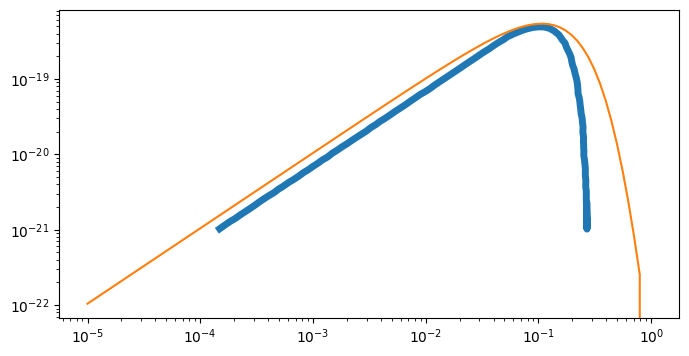

In [64]:
_x = np.logspace(-5,0,100)
Y = []
for xi in _x:

    theta = np.linspace(0., 180., 18*4)
    vals = np.array([A(xi, 1.5*eta_0, thetai)*np.sin(thetai*np.pi/180.) for thetai in theta])
    result = np.trapezoid(vals, theta)/2.*np.pi/180.

    Y.append(result*xi)

print(Y)

fig, ax = plt.subplots(1,1,figsize = (8, 4))

interp_file = ("./kelner_aharonian_2008/fig2_values/gamma_1.5eta0.txt")

x_i, spectrum = np.genfromtxt(
    interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
)

x_i = np.power(10,x_i)
spectrum = np.power(10,spectrum)

ax.loglog(x_i,spectrum,lw=5,label=r"K&A")

ax.loglog(_x,Y)
